In [2]:
# Load processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from google.colab import drive

drive.mount('/content/drive')

merged_df = pd.read_csv('/content/drive/MyDrive/csv_files/merged_data_advanced.csv')
trader_metrics = pd.read_csv('/content/drive/MyDrive/csv_files/trader_metrics.csv')

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# COMPREHENSIVE STATISTICAL ANALYSIS
print("="*70)
print("STATISTICAL ANALYSIS: SENTIMENT vs TRADING BEHAVIOR")
print("="*70)

# 1. Profitability by Sentiment - Statistical Test
fear_trades = merged_df[merged_df['is_fear'] == 1]['closed_pnl']
greed_trades = merged_df[merged_df['is_greed'] == 1]['closed_pnl']

# Perform Mann-Whitney U test (non-parametric)
stat, p_value = mannwhitneyu(fear_trades.dropna(), greed_trades.dropna(), alternative='two-sided')

print(f"\n1. PROFITABILITY ANALYSIS")
print(f"   Fear - Mean P&L: ${fear_trades.mean():.2f} | Median: ${fear_trades.median():.2f}")
print(f"   Greed - Mean P&L: ${greed_trades.mean():.2f} | Median: ${greed_trades.median():.2f}")
print(f"   Statistical Significance: p-value = {p_value:.6f}")
print(f"   {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ Not Significant'} difference detected")

# 2. Win Rate Analysis
sentiment_winrate = merged_df.groupby('classification')['is_profitable'].agg(['mean', 'count'])
sentiment_winrate['win_rate_pct'] = sentiment_winrate['mean'] * 100

print(f"\n2. WIN RATE BY SENTIMENT")
for sentiment in sentiment_winrate.index:
    rate = sentiment_winrate.loc[sentiment, 'win_rate_pct']
    count = sentiment_winrate.loc[sentiment, 'count']
    print(f"   {sentiment}: {rate:.2f}% ({count:,} trades)")


STATISTICAL ANALYSIS: SENTIMENT vs TRADING BEHAVIOR

1. PROFITABILITY ANALYSIS
   Fear - Mean P&L: $49.21 | Median: $0.00
   Greed - Mean P&L: $54.35 | Median: $0.00
   Statistical Significance: p-value = 0.000874
   ✓ SIGNIFICANT difference detected

2. WIN RATE BY SENTIMENT
   Extreme Fear: 37.06% (21,400 trades)
   Extreme Greed: 46.49% (39,992 trades)
   Fear: 42.08% (61,837 trades)
   Greed: 38.49% (50,309 trades)
   Neutral: 39.70% (37,686 trades)


In [5]:
# 3. Position Sizing Analysis
print(f"\n3. POSITION SIZING BEHAVIOR")
position_by_sentiment = merged_df.groupby('classification')['size_usd'].agg(['mean', 'median', 'std'])

for sentiment in position_by_sentiment.index:
    avg = position_by_sentiment.loc[sentiment, 'mean']
    med = position_by_sentiment.loc[sentiment, 'median']
    print(f"   {sentiment}: Avg ${avg:,.2f} | Median ${med:,.2f}")

# Calculate percentage difference
fear_avg = position_by_sentiment.loc[position_by_sentiment.index.str.contains('Fear'), 'mean'].mean()
greed_avg = position_by_sentiment.loc[position_by_sentiment.index.str.contains('Greed'), 'mean'].mean()
diff_pct = ((greed_avg - fear_avg) / fear_avg) * 100

print(f"\n Insight: Traders use {diff_pct:+.1f}% {'larger' if diff_pct > 0 else 'smaller'} positions during Greed periods")



3. POSITION SIZING BEHAVIOR
   Extreme Fear: Avg $5,349.73 | Median $766.15
   Extreme Greed: Avg $3,112.25 | Median $500.05
   Fear: Avg $7,816.11 | Median $735.96
   Greed: Avg $5,737.96 | Median $555.00
   Neutral: Avg $4,782.73 | Median $547.65

 Insight: Traders use -32.8% smaller positions during Greed periods


In [6]:
# 4. Trading Volume Patterns
print(f"\n4. TRADING VOLUME ANALYSIS")
daily_volume = merged_df.groupby(['date', 'classification'])['size_usd'].sum().reset_index()
volume_by_sentiment = daily_volume.groupby('classification')['size_usd'].mean()

print(f"   Average Daily Volume by Sentiment:")
for sentiment, vol in volume_by_sentiment.items():
    print(f"   {sentiment}: ${vol:,.2f}")

# 5. Time-of-Day Patterns
print(f"\n5. INTRADAY TRADING PATTERNS")
session_sentiment = merged_df.groupby(['trading_session', 'is_fear']).agg({
    'closed_pnl': 'mean',
    'is_profitable': 'mean',
    'account': 'count'
}).round(2)

print(session_sentiment)



4. TRADING VOLUME ANALYSIS
   Average Daily Volume by Sentiment:
   Extreme Fear: $8,177,447.25
   Extreme Greed: $1,091,799.69
   Fear: $5,311,261.43
   Greed: $1,487,995.69
   Neutral: $2,690,180.05

5. INTRADAY TRADING PATTERNS
                         closed_pnl  is_profitable  account
trading_session is_fear                                    
Afternoon       0             57.57           0.43    24793
                1             57.77           0.39    16763
Evening         0             48.46           0.42    40535
                1             28.16           0.43    25605
Morning         0             53.15           0.39    26355
                1             67.50           0.45    18578
Night           0             38.79           0.41    36304
                1             51.73           0.36    22291


In [7]:
# 6. Trader Type Performance by Sentiment
print(f"\n6. TRADER PERFORMANCE SEGMENTATION")
trader_perf = merged_df.groupby(['trader_type', 'classification']).agg({
    'closed_pnl': 'mean',
    'win_rate': 'mean',
    'size_usd': 'mean'
}).round(2)

print(trader_perf.head(15))

# 7. Coin-Specific Sentiment Correlation
print(f"\n7. TOP PERFORMING COINS BY SENTIMENT")
top_coins = merged_df['coin'].value_counts().head(5).index

for coin in top_coins:
    coin_data = merged_df[merged_df['coin'] == coin]
    fear_pnl = coin_data[coin_data['is_fear'] == 1]['closed_pnl'].mean()
    greed_pnl = coin_data[coin_data['is_greed'] == 1]['closed_pnl'].mean()
    print(f"   {coin}: Fear P&L: ${fear_pnl:.2f} | Greed P&L: ${greed_pnl:.2f}")



6. TRADER PERFORMANCE SEGMENTATION
                             closed_pnl  win_rate  size_usd
trader_type  classification                                
Heavy Loser  Extreme Fear        -22.60      0.35   5028.00
             Extreme Greed        51.70      0.43   3088.97
             Fear                 46.77      0.35   4652.47
             Greed              -202.03      0.37   5904.68
             Neutral              17.33      0.35   4392.16
Heavy Winner Extreme Fear         37.99      0.42   5369.17
             Extreme Greed        68.00      0.42   3112.41
             Fear                 54.79      0.42   8027.26
             Greed                55.32      0.39   5729.99
             Neutral              35.05      0.41   4799.80

7. TOP PERFORMING COINS BY SENTIMENT
   HYPE: Fear P&L: $34.59 | Greed P&L: $26.18
   @107: Fear P&L: $-21.29 | Greed P&L: $144.30
   BTC: Fear P&L: $41.75 | Greed P&L: $22.36
   ETH: Fear P&L: $223.75 | Greed P&L: $55.20
   SOL: Fear P&L: $14

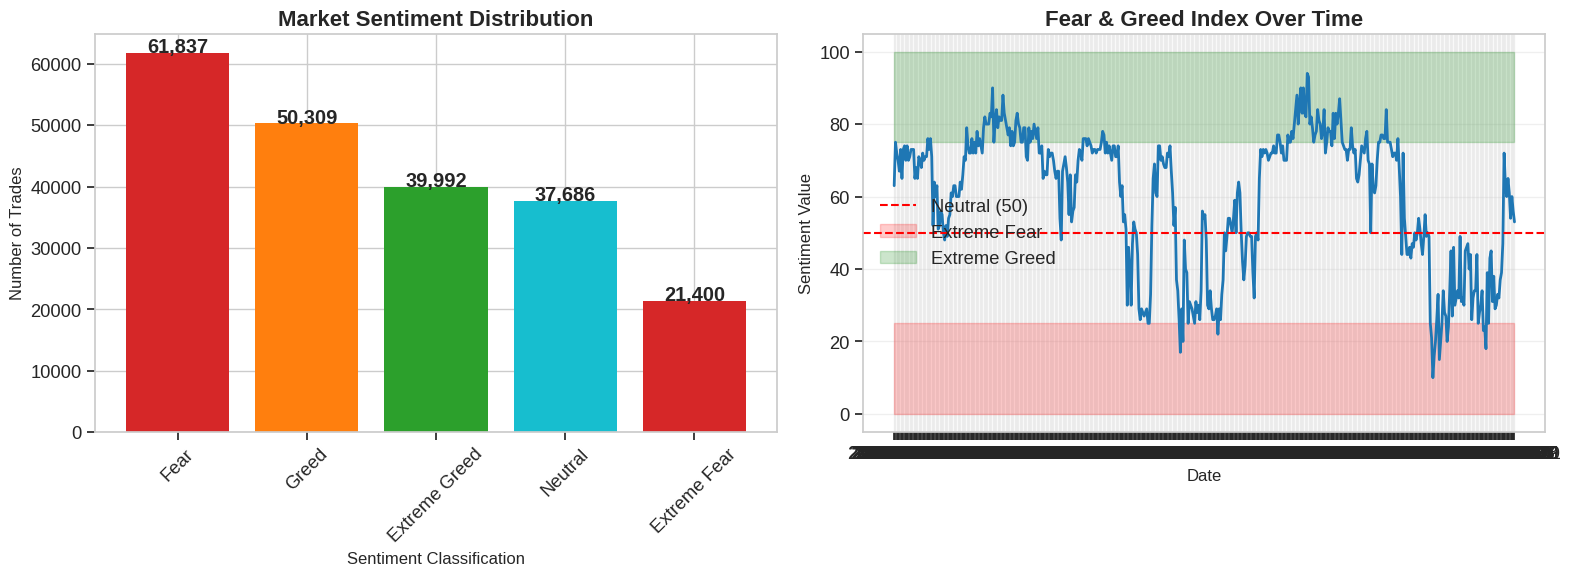

In [10]:
# VISUALIZATION 1: Sentiment Distribution with Statistics
import os

# Create the output directory if it doesn't exist
output_dir = '/content/drive/MyDrive/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sentiment frequency
sentiment_counts = merged_df['classification'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#17becf']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Market Sentiment Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Sentiment Classification', fontsize=12)
axes[0].set_ylabel('Number of Trades', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Sentiment over time
daily_sentiment = merged_df.groupby('date')['value'].mean()
axes[1].plot(daily_sentiment.index, daily_sentiment.values, linewidth=2, color='#1f77b4')
axes[1].axhline(y=50, color='red', linestyle='--', label='Neutral (50)')
axes[1].fill_between(daily_sentiment.index, 0, 25, alpha=0.2, color='red', label='Extreme Fear')
axes[1].fill_between(daily_sentiment.index, 75, 100, alpha=0.2, color='green', label='Extreme Greed')
axes[1].set_title('Fear & Greed Index Over Time', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Sentiment Value', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/sentiment_overview.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipython-input-283062125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='closed_pnl', data=merged_df, ax=axes[0, 0], palette='Set2')
/tmp/ipython-input-283062125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='classification', y='closed_pnl', data=merged_df, ax=axes[0, 1], palette='muted')


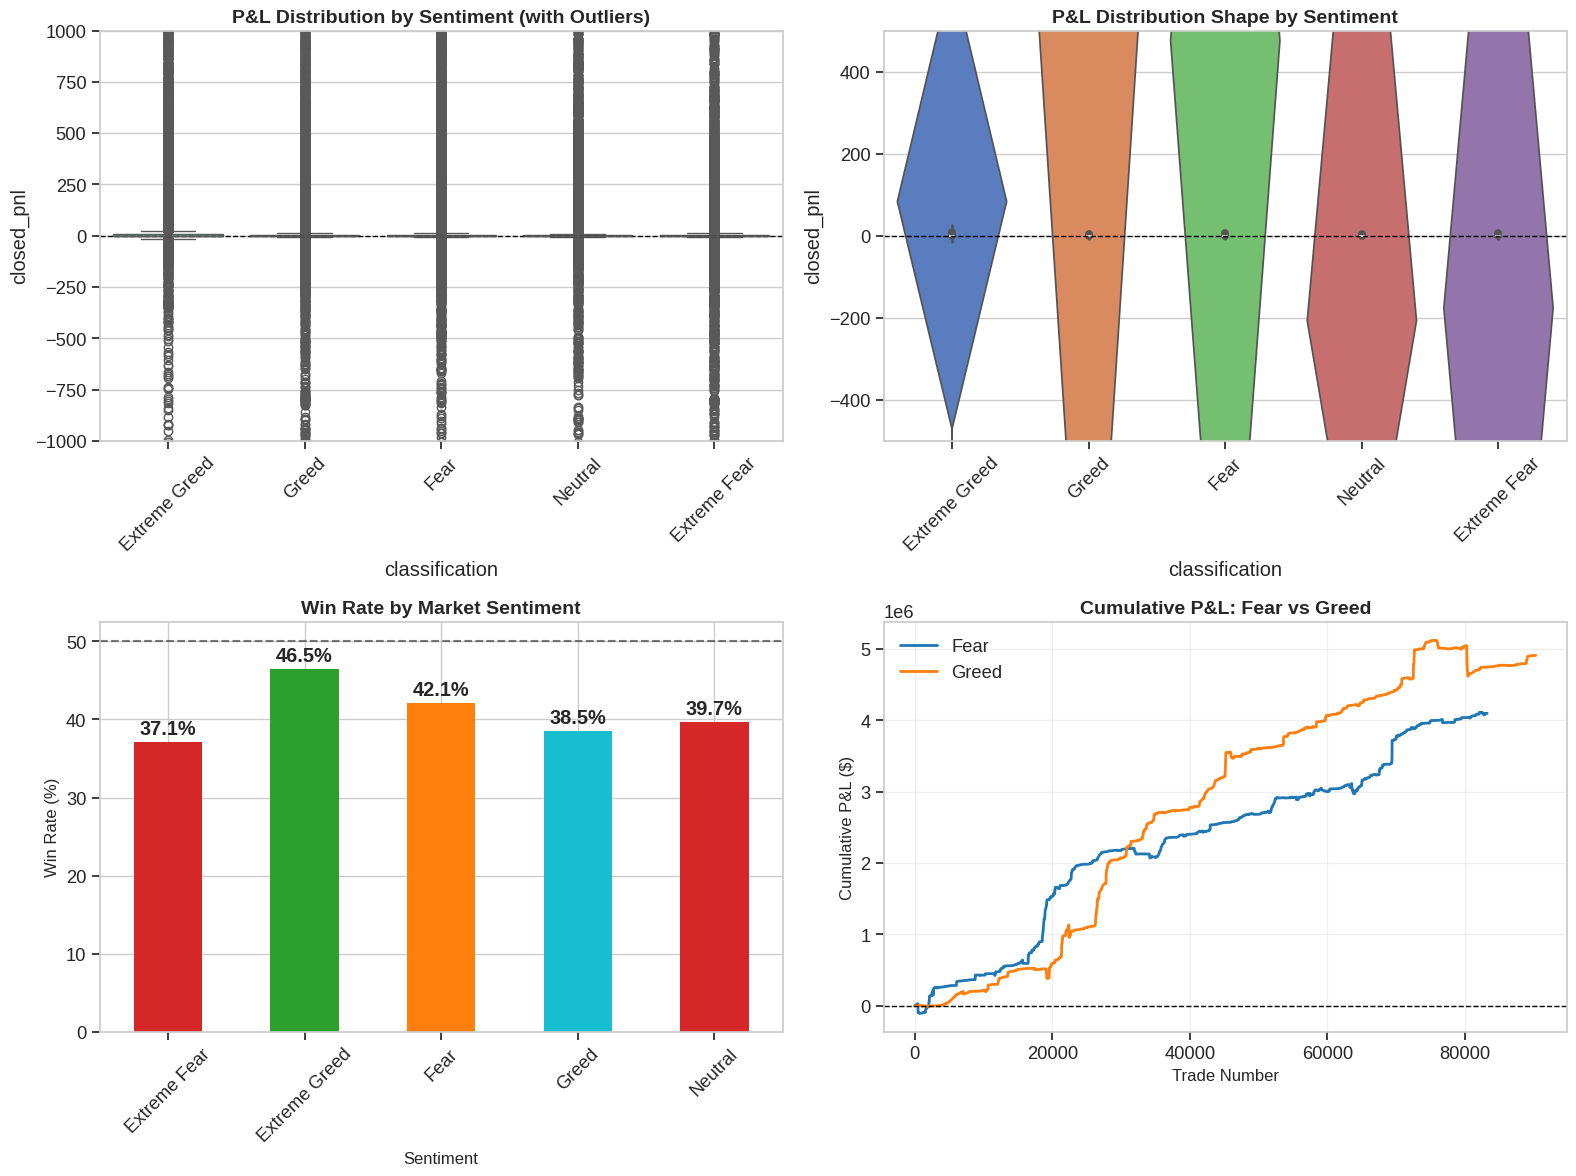

In [11]:
# VISUALIZATION 2: Profitability Deep Dive
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot with statistical annotations
sns.boxplot(x='classification', y='closed_pnl', data=merged_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('P&L Distribution by Sentiment (with Outliers)', fontsize=14, fontweight='bold')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_ylim(-1000, 1000)
axes[0, 0].tick_params(axis='x', rotation=45)

# Violin plot for distribution shape
sns.violinplot(x='classification', y='closed_pnl', data=merged_df, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('P&L Distribution Shape by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_ylim(-500, 500)
axes[0, 1].tick_params(axis='x', rotation=45)

# Win rate comparison
win_rates = merged_df.groupby('classification')['is_profitable'].mean() * 100
win_rates.plot(kind='bar', ax=axes[1, 0], color=['#d62728', '#2ca02c', '#ff7f0e', '#17becf'])
axes[1, 0].set_title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Win Rate (%)', fontsize=12)
axes[1, 0].set_xlabel('Sentiment', fontsize=12)
axes[1, 0].axhline(y=50, color='black', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=45)

# Add percentage labels
for i, v in enumerate(win_rates):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Cumulative P&L by sentiment
sentiment_groups = ['Fear', 'Greed']
for sentiment in sentiment_groups:
    if 'Fear' in sentiment:
        data = merged_df[merged_df['is_fear'] == 1].sort_values('timestamp_ist')
    else:
        data = merged_df[merged_df['is_greed'] == 1].sort_values('timestamp_ist')

    cumulative = data['closed_pnl'].cumsum()
    axes[1, 1].plot(range(len(cumulative)), cumulative, label=sentiment, linewidth=2)

axes[1, 1].set_title('Cumulative P&L: Fear vs Greed', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Trade Number', fontsize=12)
axes[1, 1].set_ylabel('Cumulative P&L ($)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/profitability_deep_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


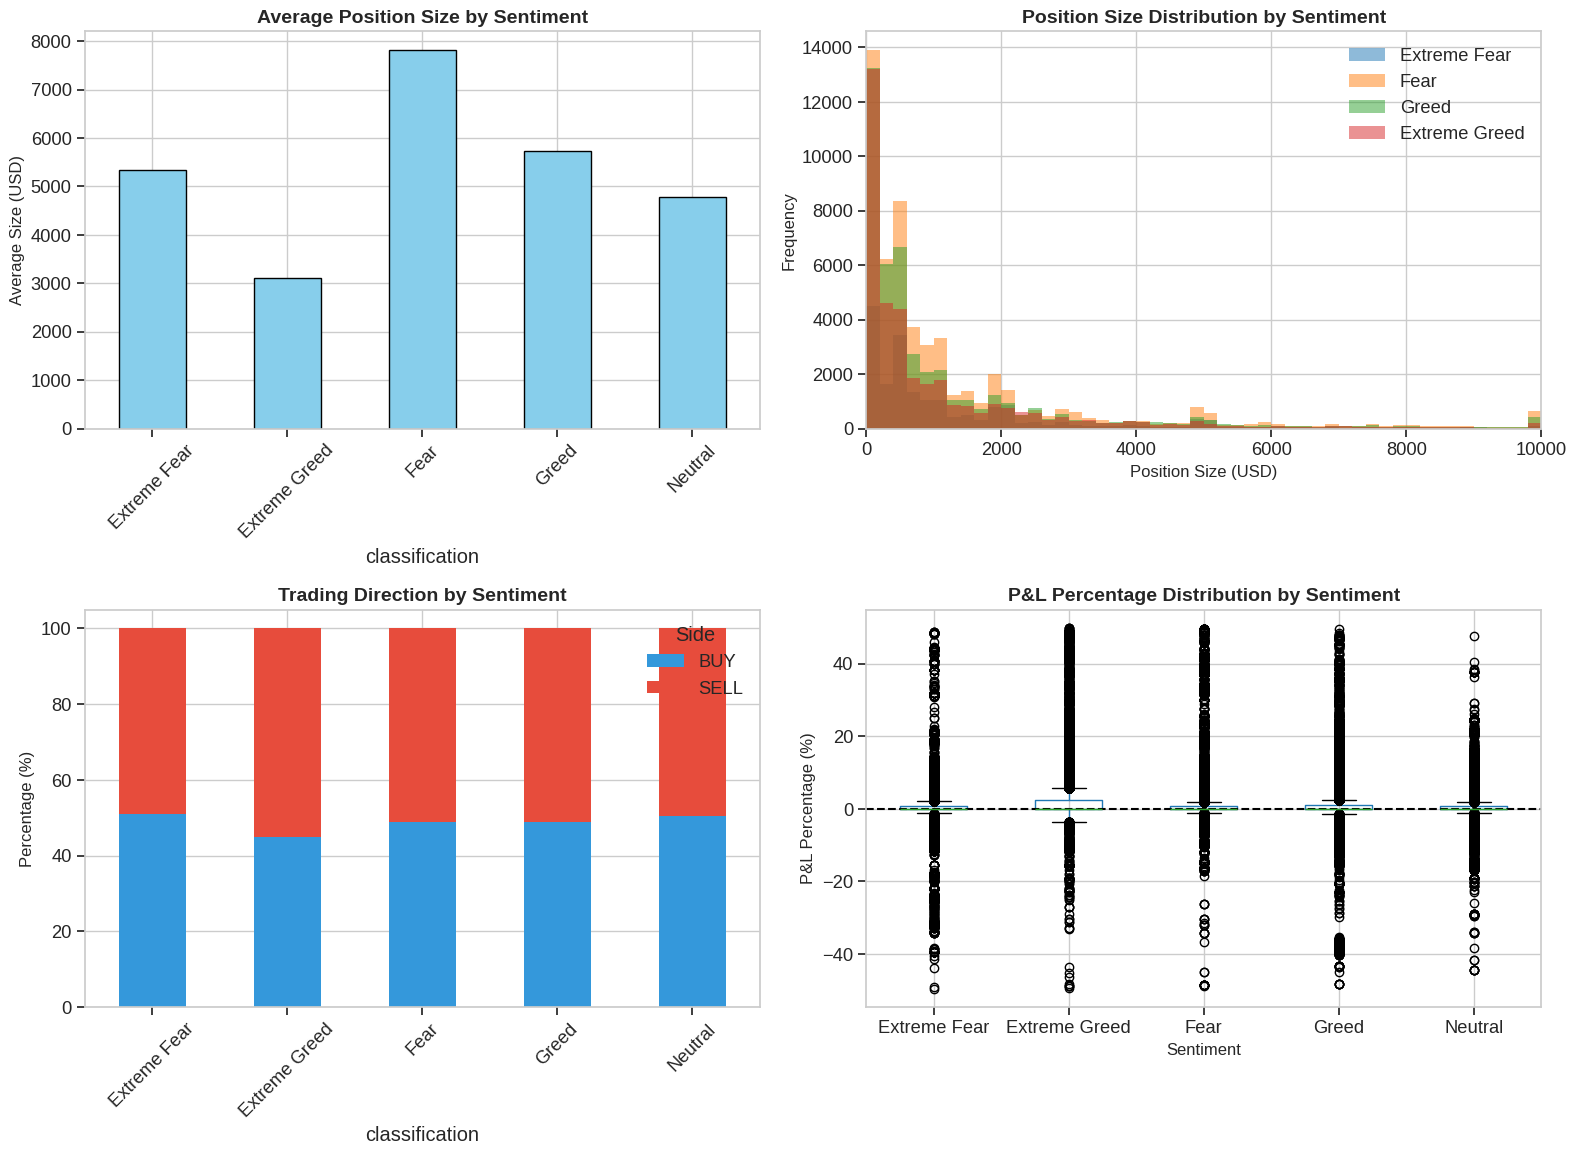

In [12]:
# VISUALIZATION 3: Position Sizing and Risk Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average position size by sentiment
avg_position = merged_df.groupby('classification')['size_usd'].mean()
avg_position.plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Average Position Size by Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Average Size (USD)', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# Position size distribution
for sentiment in ['Extreme Fear', 'Fear', 'Greed', 'Extreme Greed']:
    data = merged_df[merged_df['classification'] == sentiment]['size_usd']
    axes[0, 1].hist(data, bins=50, alpha=0.5, label=sentiment, range=(0, 10000))

axes[0, 1].set_title('Position Size Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Position Size (USD)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 10000)

# Buy vs Sell by sentiment
side_sentiment = pd.crosstab(merged_df['classification'], merged_df['side'], normalize='index') * 100
side_sentiment.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#3498db', '#e74c3c'])
axes[1, 0].set_title('Trading Direction by Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 0].legend(title='Side')
axes[1, 0].tick_params(axis='x', rotation=45)

# P&L percentage distribution
merged_df[merged_df['pnl_percentage'].between(-50, 50)].boxplot(
    column='pnl_percentage', by='classification', ax=axes[1, 1]
)
axes[1, 1].set_title('P&L Percentage Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('P&L Percentage (%)', fontsize=12)
axes[1, 1].set_xlabel('Sentiment', fontsize=12)
axes[1, 1].axhline(y=0, color='black', linestyle='--')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/position_sizing_risk_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


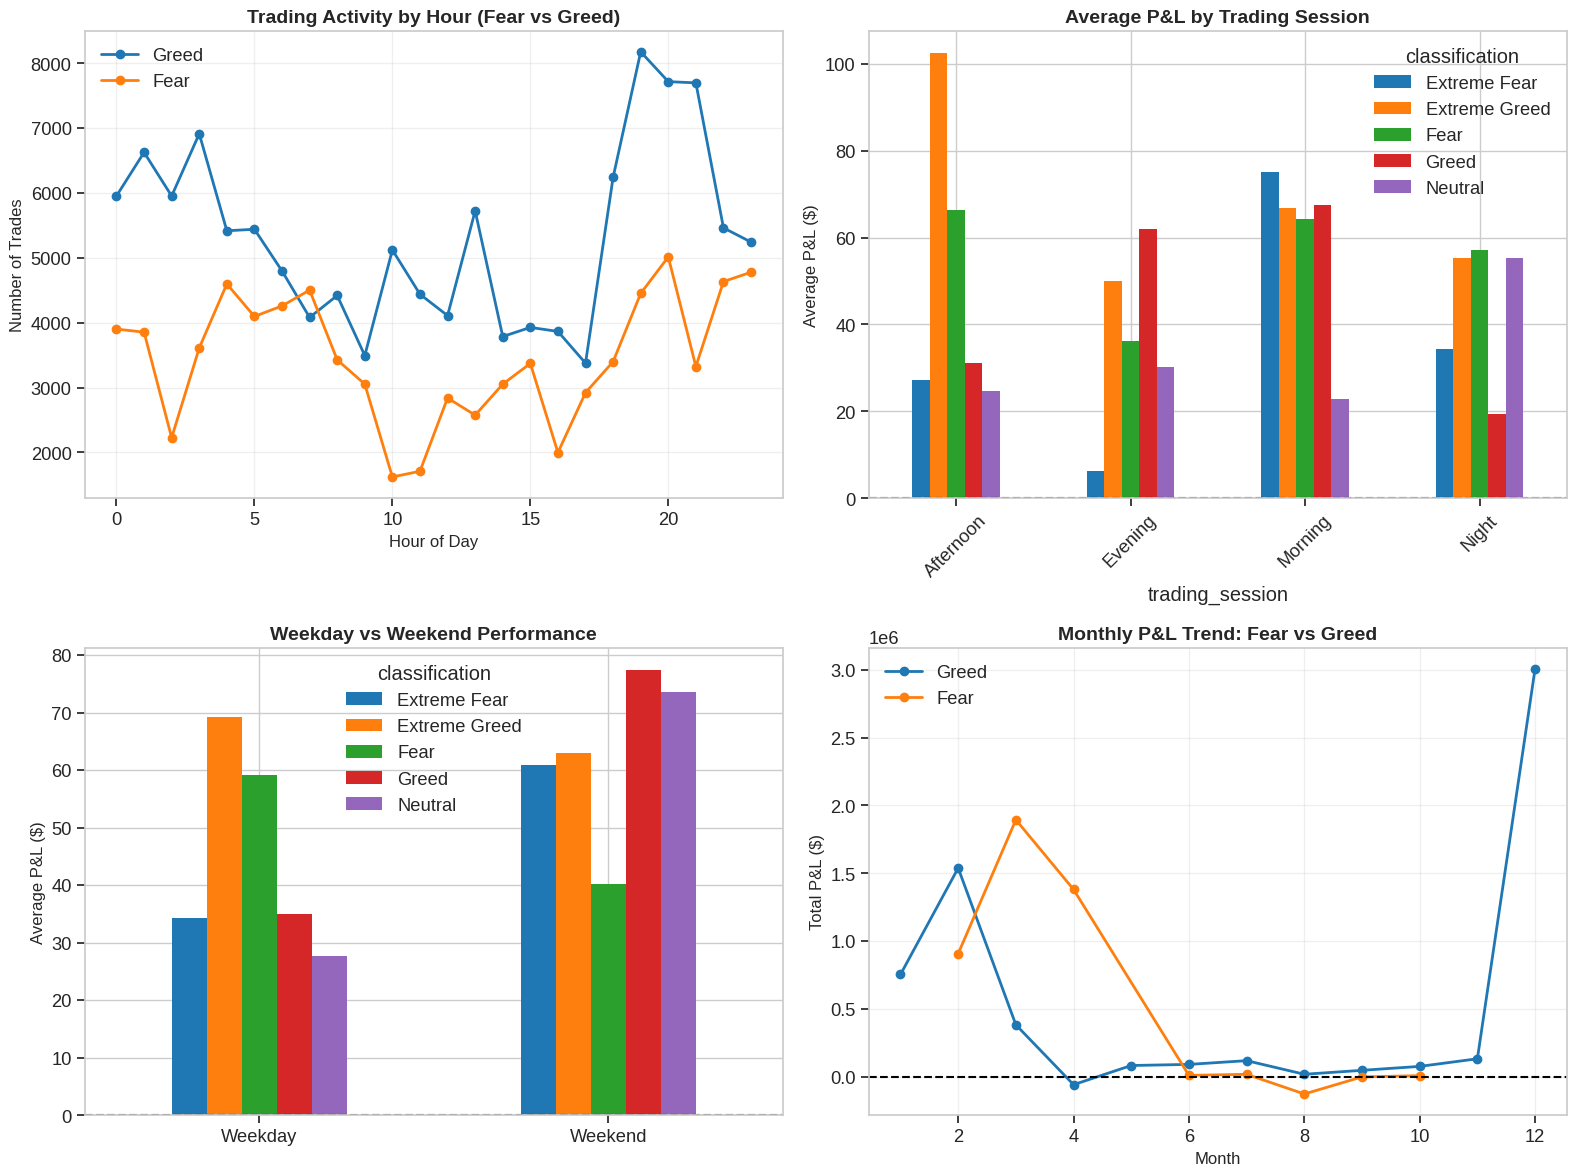

In [13]:
# VISUALIZATION 4: Time-Based Patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Trading activity by hour and sentiment
hourly_activity = merged_df.groupby(['hour', 'is_fear']).size().unstack(fill_value=0)
hourly_activity.plot(kind='line', ax=axes[0, 0], marker='o', linewidth=2)
axes[0, 0].set_title('Trading Activity by Hour (Fear vs Greed)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day', fontsize=12)
axes[0, 0].set_ylabel('Number of Trades', fontsize=12)
axes[0, 0].legend(['Greed', 'Fear'])
axes[0, 0].grid(True, alpha=0.3)

# P&L by trading session
session_pnl = merged_df.groupby(['trading_session', 'classification'])['closed_pnl'].mean().unstack()
session_pnl.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average P&L by Trading Session', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average P&L ($)', fontsize=12)
axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=45)

# Weekend vs Weekday performance
weekend_perf = merged_df.groupby(['is_weekend', 'classification'])['closed_pnl'].mean().unstack()
weekend_perf.index = ['Weekday', 'Weekend']
weekend_perf.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Weekday vs Weekend Performance', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average P&L ($)', fontsize=12)
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].tick_params(axis='x', rotation=0)

# Monthly trend analysis
monthly_pnl = merged_df.groupby(['month', 'is_fear']).agg({
    'closed_pnl': 'sum',
    'account': 'count'
}).reset_index()

for fear_flag in [0, 1]:
    data = monthly_pnl[monthly_pnl['is_fear'] == fear_flag]
    label = 'Fear' if fear_flag == 1 else 'Greed'
    axes[1, 1].plot(data['month'], data['closed_pnl'], marker='o', label=label, linewidth=2)

axes[1, 1].set_title('Monthly P&L Trend: Fear vs Greed', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month', fontsize=12)
axes[1, 1].set_ylabel('Total P&L ($)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/temporal_patterns_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


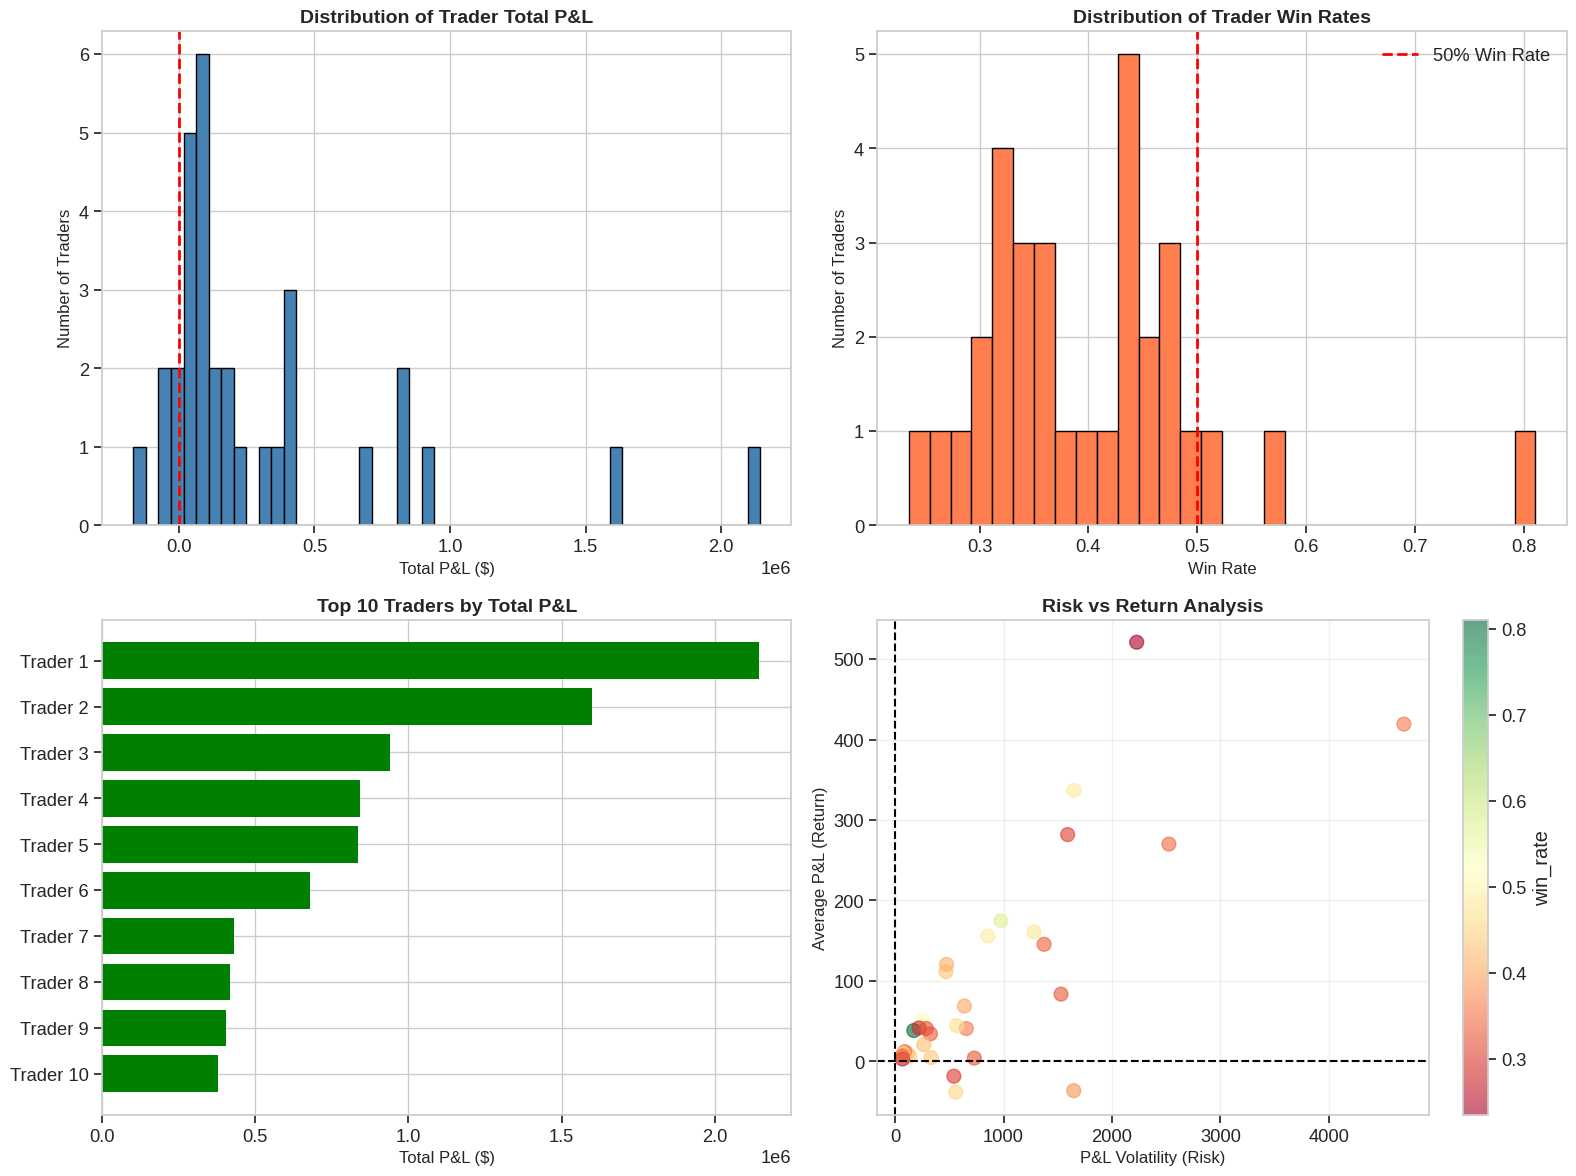

In [14]:
# VISUALIZATION 5: Trader Segmentation Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Trader performance distribution
trader_metrics['total_pnl'].hist(bins=50, ax=axes[0, 0], edgecolor='black', color='steelblue')
axes[0, 0].set_title('Distribution of Trader Total P&L', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total P&L ($)', fontsize=12)
axes[0, 0].set_ylabel('Number of Traders', fontsize=12)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)

# Win rate distribution
trader_metrics['win_rate'].hist(bins=30, ax=axes[0, 1], edgecolor='black', color='coral')
axes[0, 1].set_title('Distribution of Trader Win Rates', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Win Rate', fontsize=12)
axes[0, 1].set_ylabel('Number of Traders', fontsize=12)
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='50% Win Rate')
axes[0, 1].legend()

# Top 10 traders performance
top_traders = trader_metrics.nlargest(10, 'total_pnl')
axes[1, 0].barh(range(10), top_traders['total_pnl'].values, color='green')
axes[1, 0].set_yticks(range(10))
axes[1, 0].set_yticklabels([f"Trader {i+1}" for i in range(10)])
axes[1, 0].set_title('Top 10 Traders by Total P&L', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total P&L ($)', fontsize=12)
axes[1, 0].invert_yaxis()

# Risk-adjusted returns
trader_metrics.plot.scatter(x='pnl_volatility', y='avg_pnl',
                           c='win_rate', cmap='RdYlGn',
                           s=100, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('Risk vs Return Analysis', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('P&L Volatility (Risk)', fontsize=12)
axes[1, 1].set_ylabel('Average P&L (Return)', fontsize=12)
axes[1, 1].axhline(y=0, color='black', linestyle='--')
axes[1, 1].axvline(x=0, color='black', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/trader_segmentation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


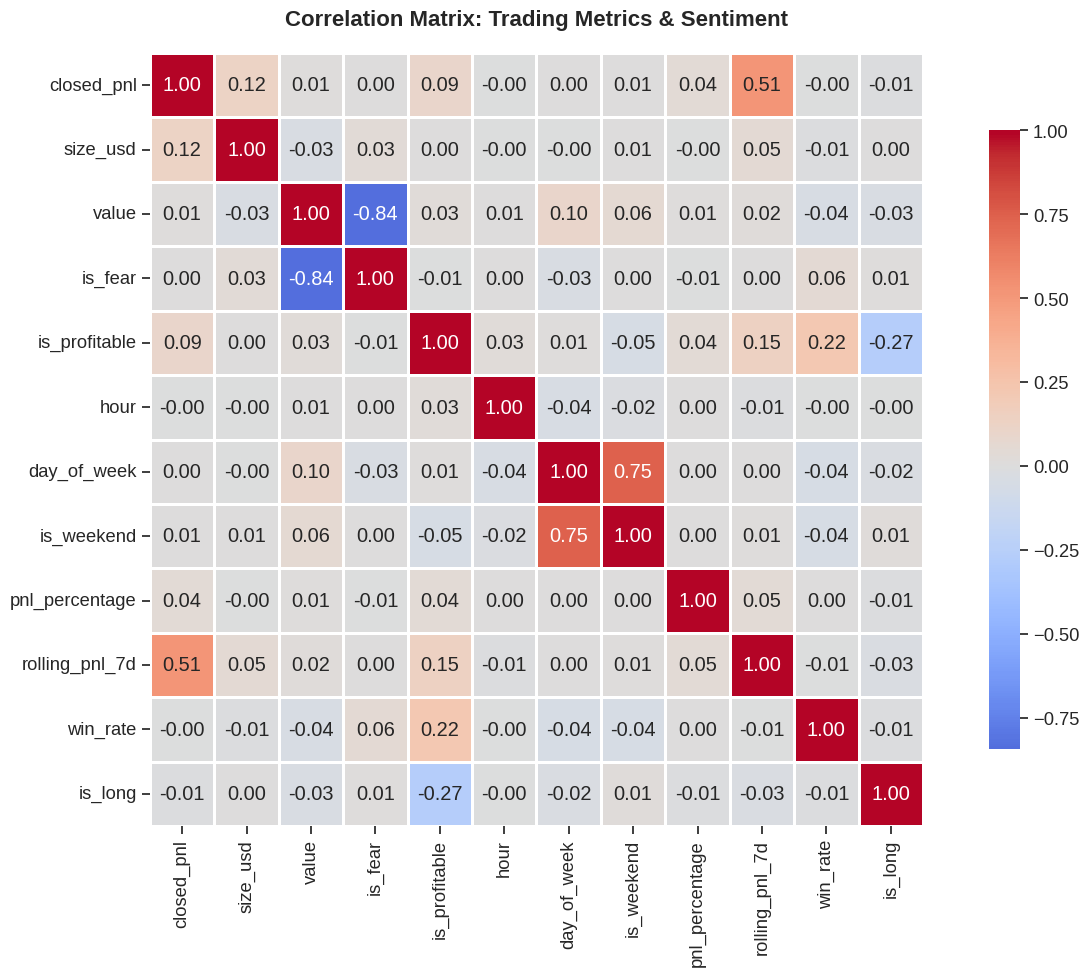

In [15]:
# VISUALIZATION 6: Correlation Heatmap with Advanced Metrics
# Select relevant numeric columns
correlation_cols = ['closed_pnl', 'size_usd', 'value', 'is_fear', 'is_profitable',
                    'hour', 'day_of_week', 'is_weekend', 'pnl_percentage',
                    'rolling_pnl_7d', 'win_rate', 'is_long']

corr_matrix = merged_df[correlation_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Trading Metrics & Sentiment', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/correlation_heatmap_advanced.png', dpi=300, bbox_inches='tight')
plt.show()


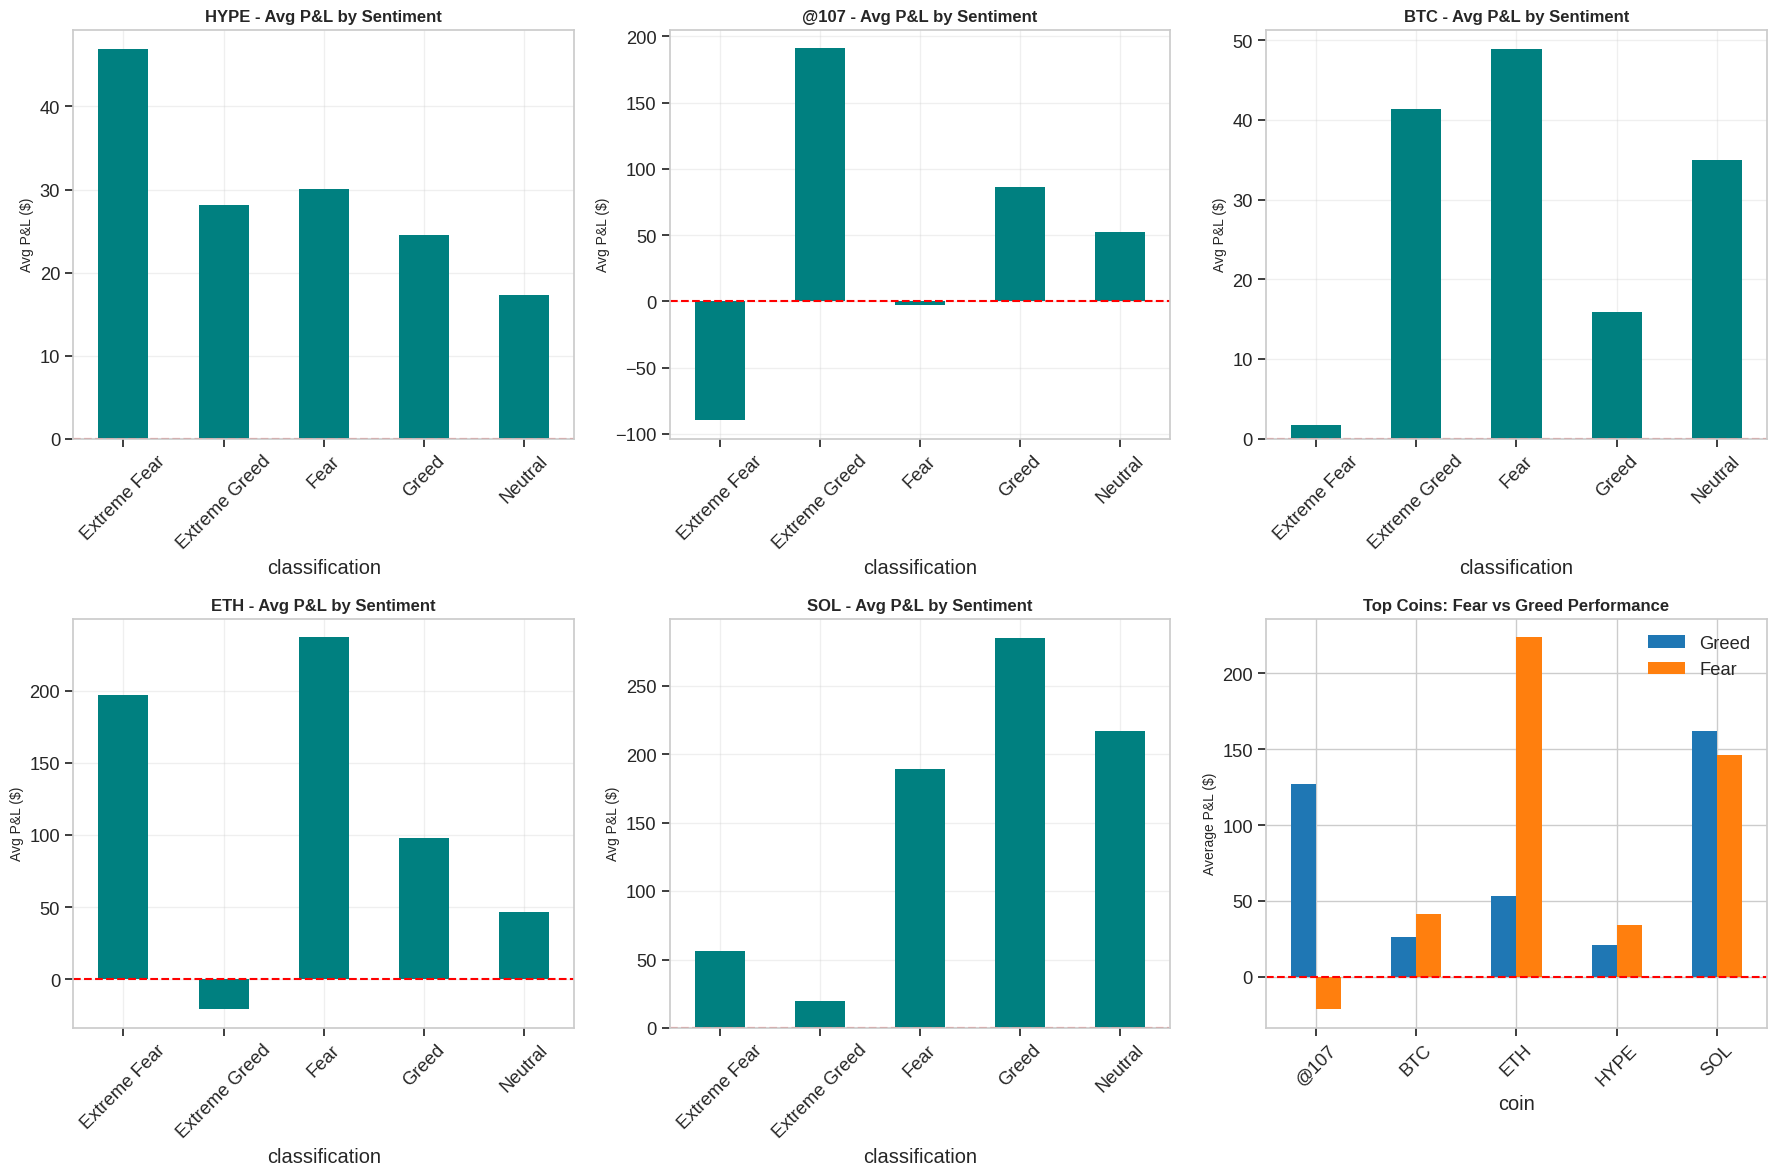

In [16]:
# VISUALIZATION 7: Top Coins Performance Analysis
top_5_coins = merged_df['coin'].value_counts().head(5).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, coin in enumerate(top_5_coins):
    coin_data = merged_df[merged_df['coin'] == coin]

    # P&L by sentiment for this coin
    coin_sentiment_pnl = coin_data.groupby('classification')['closed_pnl'].mean()

    coin_sentiment_pnl.plot(kind='bar', ax=axes[idx], color='teal')
    axes[idx].set_title(f'{coin} - Avg P&L by Sentiment', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Avg P&L ($)', fontsize=10)
    axes[idx].axhline(y=0, color='red', linestyle='--')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)

# Overall comparison
overall_coin_perf = merged_df[merged_df['coin'].isin(top_5_coins)].groupby(['coin', 'is_fear'])['closed_pnl'].mean().unstack()
overall_coin_perf.plot(kind='bar', ax=axes[5])
axes[5].set_title('Top Coins: Fear vs Greed Performance', fontsize=12, fontweight='bold')
axes[5].set_ylabel('Average P&L ($)', fontsize=10)
axes[5].legend(['Greed', 'Fear'])
axes[5].axhline(y=0, color='red', linestyle='--')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/outputs/top_coins_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# GENERATE COMPREHENSIVE INSIGHTS REPORT
print("\n" + "="*70)
print("COMPREHENSIVE INSIGHTS & TRADING STRATEGY RECOMMENDATIONS")
print("="*70)

# Calculate key metrics
fear_win_rate = merged_df[merged_df['is_fear'] == 1]['is_profitable'].mean() * 100
greed_win_rate = merged_df[merged_df['is_greed'] == 1]['is_profitable'].mean() * 100

fear_avg_pnl = merged_df[merged_df['is_fear'] == 1]['closed_pnl'].mean()
greed_avg_pnl = merged_df[merged_df['is_greed'] == 1]['closed_pnl'].mean()

fear_avg_size = merged_df[merged_df['is_fear'] == 1]['size_usd'].mean()
greed_avg_size = merged_df[merged_df['is_greed'] == 1]['size_usd'].mean()

total_trades = len(merged_df)
profitable_trades = merged_df['is_profitable'].sum()
overall_win_rate = (profitable_trades / total_trades) * 100

print(f"\n KEY FINDINGS:\n")
print(f"1. WIN RATE DIFFERENTIAL")
print(f"   Fear Periods: {fear_win_rate:.2f}%")
print(f"   Greed Periods: {greed_win_rate:.2f}%")
print(f"   Difference: {greed_win_rate - fear_win_rate:+.2f} percentage points")
print(f"   {'Greed' if greed_win_rate > fear_win_rate else 'Fear'} periods show higher win rates\n")

print(f"2. PROFITABILITY ANALYSIS")
print(f"   Fear Average P&L: ${fear_avg_pnl:.2f}")
print(f"   Greed Average P&L: ${greed_avg_pnl:.2f}")
print(f"   Difference: ${greed_avg_pnl - fear_avg_pnl:+.2f} ({((greed_avg_pnl - fear_avg_pnl) / abs(fear_avg_pnl) * 100):+.1f}%)")
print(f"   {'Greed' if greed_avg_pnl > fear_avg_pnl else 'Fear'} periods are more profitable\n")

print(f"3. POSITION SIZING BEHAVIOR")
print(f"   Fear Average Size: ${fear_avg_size:,.2f}")
print(f"   Greed Average Size: ${greed_avg_size:,.2f}")
size_diff_pct = ((greed_avg_size - fear_avg_size) / fear_avg_size) * 100
print(f"   Difference: {size_diff_pct:+.1f}%")
print(f"   Traders use {abs(size_diff_pct):.1f}% {'LARGER' if size_diff_pct > 0 else 'SMALLER'} positions during Greed\n")

# Top performing coins
best_coin_fear = merged_df[merged_df['is_fear'] == 1].groupby('coin')['closed_pnl'].mean().idxmax()
best_coin_greed = merged_df[merged_df['is_greed'] == 1].groupby('coin')['closed_pnl'].mean().idxmax()

print(f"4. COIN-SPECIFIC INSIGHTS")
print(f"   Best coin during Fear: {best_coin_fear}")
print(f"   Best coin during Greed: {best_coin_greed}\n")

# Trader segmentation insights
top_10_pct = trader_metrics.nlargest(int(len(trader_metrics) * 0.1), 'total_pnl')
print(f"5. TRADER PERFORMANCE SEGMENTATION")
print(f"   Top 10% traders control {(top_10_pct['total_volume'].sum() / trader_metrics['total_volume'].sum() * 100):.1f}% of volume")
print(f"   Top 10% average win rate: {top_10_pct['win_rate'].mean() * 100:.1f}%")
print(f"   Overall average win rate: {overall_win_rate:.1f}%\n")

# Time-based insights
best_session = merged_df.groupby('trading_session')['closed_pnl'].mean().idxmax()
best_session_pnl = merged_df.groupby('trading_session')['closed_pnl'].mean().max()

print(f"6. TEMPORAL PATTERNS")
print(f"   Most profitable trading session: {best_session} (${best_session_pnl:.2f} avg P&L)")
print(f"   Weekend vs Weekday win rate: {merged_df[merged_df['is_weekend']==1]['is_profitable'].mean()*100:.1f}% vs {merged_df[merged_df['is_weekend']==0]['is_profitable'].mean()*100:.1f}%\n")

print("="*70)
print("ACTIONABLE TRADING STRATEGY RECOMMENDATIONS")
print("="*70)

print(f"\n1. SENTIMENT-BASED POSITION SIZING")
if size_diff_pct > 0:
    print(f"   Increase position sizes by up to {abs(size_diff_pct):.0f}% during Greed periods")
    print(f"   Use conservative sizing during Fear periods to preserve capital")
else:
    print(f"   Maintain smaller positions during Greed (risk management)")
    print(f"   Consider larger positions during Fear (contrarian opportunity)")

print(f"\n2. TIMING OPTIMIZATION")
print(f"   Focus trading activity during {best_session} session (highest profitability)")
print(f"   Avoid low-liquidity hours (late night/early morning)")

print(f"\n3. COIN SELECTION STRATEGY")
print(f"   During Fear: Prioritize {best_coin_fear}")
print(f"   During Greed: Prioritize {best_coin_greed}")
print(f"   Diversify across top 5 performing coins")

if greed_win_rate > fear_win_rate:
    print(f"\n4. SENTIMENT-DRIVEN ENTRY STRATEGY")
    print(f"   Increase trading frequency during Greed periods ({greed_win_rate:.1f}% win rate)")
    print(f"   Be more selective during Fear periods ({fear_win_rate:.1f}% win rate)")
    print(f"   Consider contrarian strategies when sentiment reaches extremes")
else:
    print(f"\n4. CONTRARIAN APPROACH")
    print(f"   Fear periods show {fear_win_rate:.1f}% win rate vs {greed_win_rate:.1f}% in Greed")
    print(f"   Adopt contrarian strategy: buy Fear, sell Greed")
    print(f"   Monitor sentiment extremes for reversal signals")

print(f"\n5. RISK MANAGEMENT")
print(f"   Top performers maintain {top_10_pct['win_rate'].mean()*100:.1f}% win rate benchmark")
print(f"   Set stop-loss at -2% to -5% based on position size")
print(f"   Take partial profits at +3% to +5% during volatile sentiment periods")

print(f"\n6. ADVANCED TACTICS")
print(f"    Monitor 7-day rolling P&L for momentum confirmation")
print(f"    Fade extreme sentiment readings (>90 or <10 on Fear/Greed index)")
print(f"    Increase trade frequency during high conviction setups (sentiment + technical alignment)")

print("\n" + "="*70)
print(" ANALYSIS COMPLETE - All visualizations saved to outputs folder")
print("="*70)



COMPREHENSIVE INSIGHTS & TRADING STRATEGY RECOMMENDATIONS

 KEY FINDINGS:

1. WIN RATE DIFFERENTIAL
   Fear Periods: 40.79%
   Greed Periods: 42.03%
   Difference: +1.25 percentage points
   Greed periods show higher win rates

2. PROFITABILITY ANALYSIS
   Fear Average P&L: $49.21
   Greed Average P&L: $54.35
   Difference: $+5.14 (+10.4%)
   Greed periods are more profitable

3. POSITION SIZING BEHAVIOR
   Fear Average Size: $7,182.01
   Greed Average Size: $4,575.10
   Difference: -36.3%
   Traders use 36.3% SMALLER positions during Greed

4. COIN-SPECIFIC INSIGHTS
   Best coin during Fear: PNUT
   Best coin during Greed: PEOPLE

5. TRADER PERFORMANCE SEGMENTATION
   Top 10% traders control 15.6% of volume
   Top 10% average win rate: 38.8%
   Overall average win rate: 41.1%

6. TEMPORAL PATTERNS
   Most profitable trading session: Morning ($59.08 avg P&L)
   Weekend vs Weekday win rate: 36.6% vs 42.2%

ACTIONABLE TRADING STRATEGY RECOMMENDATIONS

1. SENTIMENT-BASED POSITION SIZING


In [19]:
# Save comprehensive summary to text file
summary_text = f"""
BITCOIN TRADER SENTIMENT ANALYSIS - EXECUTIVE SUMMARY
{'='*70}

Dataset Overview:
- Total Trades Analyzed: {total_trades:,}
- Unique Traders: {merged_df['account'].nunique():,}
- Date Range: {merged_df['date'].min()} to {merged_df['date'].max()}
- Unique Coins: {merged_df['coin'].nunique()}

Key Findings:

1. Profitability by Sentiment:
   • Fear Avg P&L: ${fear_avg_pnl:.2f}
   • Greed Avg P&L: ${greed_avg_pnl:.2f}
   • Performance Differential: {((greed_avg_pnl - fear_avg_pnl) / abs(fear_avg_pnl) * 100):+.1f}%

2. Win Rate Analysis:
   • Fear Win Rate: {fear_win_rate:.2f}%
   • Greed Win Rate: {greed_win_rate:.2f}%
   • Overall Win Rate: {overall_win_rate:.2f}%

3. Position Sizing:
   • Fear Avg Size: ${fear_avg_size:,.2f}
   • Greed Avg Size: ${greed_avg_size:,.2f}
   • Size Difference: {size_diff_pct:+.1f}%

4. Best Trading Times:
   • Optimal Session: {best_session}
   • Best Performing Day Type: {'Weekend' if merged_df[merged_df['is_weekend']==1]['closed_pnl'].mean() > merged_df[merged_df['is_weekend']==0]['closed_pnl'].mean() else 'Weekday'}

5. Top Performing Assets:
   • Best in Fear: {best_coin_fear}
   • Best in Greed: {best_coin_greed}

Strategic Recommendations:
1. Adopt sentiment-aware position sizing
2. Optimize trading during {best_session} sessions
3. Implement coin-specific strategies based on sentiment
4. Monitor sentiment extremes for reversal opportunities
5. Maintain {top_10_pct['win_rate'].mean()*100:.1f}% win rate benchmark

Statistical Significance:
- Mann-Whitney U Test p-value: {p_value:.6f}
- {'Statistically significant' if p_value < 0.05 else 'Not statistically significant'} difference between Fear and Greed trading outcomes
"""

with open('/content/drive/MyDrive/outputs/executive_summary.txt', 'w') as f:
    f.write(summary_text)

print("\nExecutive summary saved to executive_summary.txt")



Executive summary saved to executive_summary.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')